In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pca import pca
import matplotlib.pyplot as plt

In [2]:
milk=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\milk.csv",index_col=0)
milk

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35
ORANGUTAN,88.5,1.4,3.5,6.0,0.24
MONKEY,88.4,2.2,2.7,6.4,0.18
DONKEY,90.3,1.7,1.4,6.2,0.40
HIPPO,90.4,0.6,4.5,4.4,0.10
CAMEL,87.7,3.5,3.4,4.8,0.71
BISON,86.9,4.8,1.7,5.7,0.90
BUFFALO,82.1,5.9,7.9,4.7,0.78
GUINEA PIG,81.9,7.4,7.2,2.7,0.85


In [3]:
milk.shape

(25, 5)

In [4]:
scaler=StandardScaler().set_output(transform="pandas")
milk_scaled=scaler.fit_transform(milk)

In [5]:
prcomp=PCA().set_output(transform="pandas")
pc_data=prcomp.fit_transform(milk_scaled)
pc_data.var()

pca0    4.040412
pca1    0.924372
pca2    0.134291
pca3    0.102689
pca4    0.006570
dtype: float64

In [6]:
pc_data

,pca0,pca1,pca2,pca3,pca4
Animal,,,,,
HORSE,2.435175,-0.231478,0.330150,0.307664,0.048184
ORANGUTAN,2.258736,-0.693148,0.029035,-0.081057,-0.000532
MONKEY,2.335861,-0.663328,0.101257,0.247997,0.010109
DONKEY,2.318677,-0.273815,0.109881,-0.092873,-0.006769
HIPPO,2.060294,-1.019199,-0.762436,-0.510091,0.029382
CAMEL,1.301536,0.137303,-0.198742,-0.282160,-0.014668
BISON,1.282742,0.622667,0.253785,0.065148,-0.044486
BUFFALO,0.505068,0.088235,0.008383,0.133774,0.083806
GUINEA PIG,-0.255502,0.287373,-0.881857,-0.013100,-0.016484


In [7]:
values,vectors=np.linalg.eig(milk_scaled.cov())
print("Eigen Values:",values)

Eigen Values: [4.0404117  0.92437238 0.00656977 0.13429088 0.1026886 ]


In [8]:
vectors

array([[-0.47294379,  0.35285509, -0.70967042,  0.36921298,  0.10893632],
       [ 0.46657047,  0.32094099, -0.1930657 ,  0.15196177, -0.78672876],
       [ 0.44868269, -0.47603724, -0.66831106, -0.30699163,  0.17660367],
       [-0.48289116,  0.05951482, -0.11159049, -0.77642589, -0.38468756],
       [ 0.35232959,  0.73643513,  0.00118661, -0.378825  ,  0.43590982]])

In [9]:
milk.columns

Index(['water', 'protein', 'fat', 'lactose', 'ash'], dtype='str')

Matrix of Eigen vectors

In [10]:
prcomp.components_

array([[ 0.47294379, -0.46657047, -0.44868269,  0.48289116, -0.35232959],
       [ 0.35285509,  0.32094099, -0.47603724,  0.05951482,  0.73643513],
       [-0.36921298, -0.15196177,  0.30699163,  0.77642589,  0.378825  ],
       [-0.10893632,  0.78672876, -0.17660367,  0.38468756, -0.43590982],
       [ 0.70967042,  0.1930657 ,  0.66831106,  0.11159049, -0.00118661]])

In [11]:
prcomp.explained_variance_ / np.sum(prcomp.explained_variance_)

array([0.77575905, 0.1774795 , 0.02578385, 0.01971621, 0.0012614 ])

In [12]:
prcomp.explained_variance_ratio_*100

array([77.57590469, 17.74794969,  2.57838496,  1.97162103,  0.12613963])

In [13]:
np.cumsum(prcomp.explained_variance_ratio_*100)

array([ 77.57590469,  95.32385438,  97.90223934,  99.87386037,
       100.        ])

[24-04-2026 16:30:59] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 5 columns of the input data.
[24-04-2026 16:30:59] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:30:59] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:30:59] [pca.pca] [INFO] Compute explained variance.
[24-04-2026 16:30:59] [pca.pca] [INFO] The top 2 principal component(s) explains >= 95.00% of the explained variance.
[24-04-2026 16:30:59] [pca.pca] [INFO] The PCA reduction is performed on 5 variables (columns) of the input dataframe.
[24-04-2026 16:30:59] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:30:59] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:30:59] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[24-04-2026 16:30:59] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[24-04-2026 16:30:59] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[24

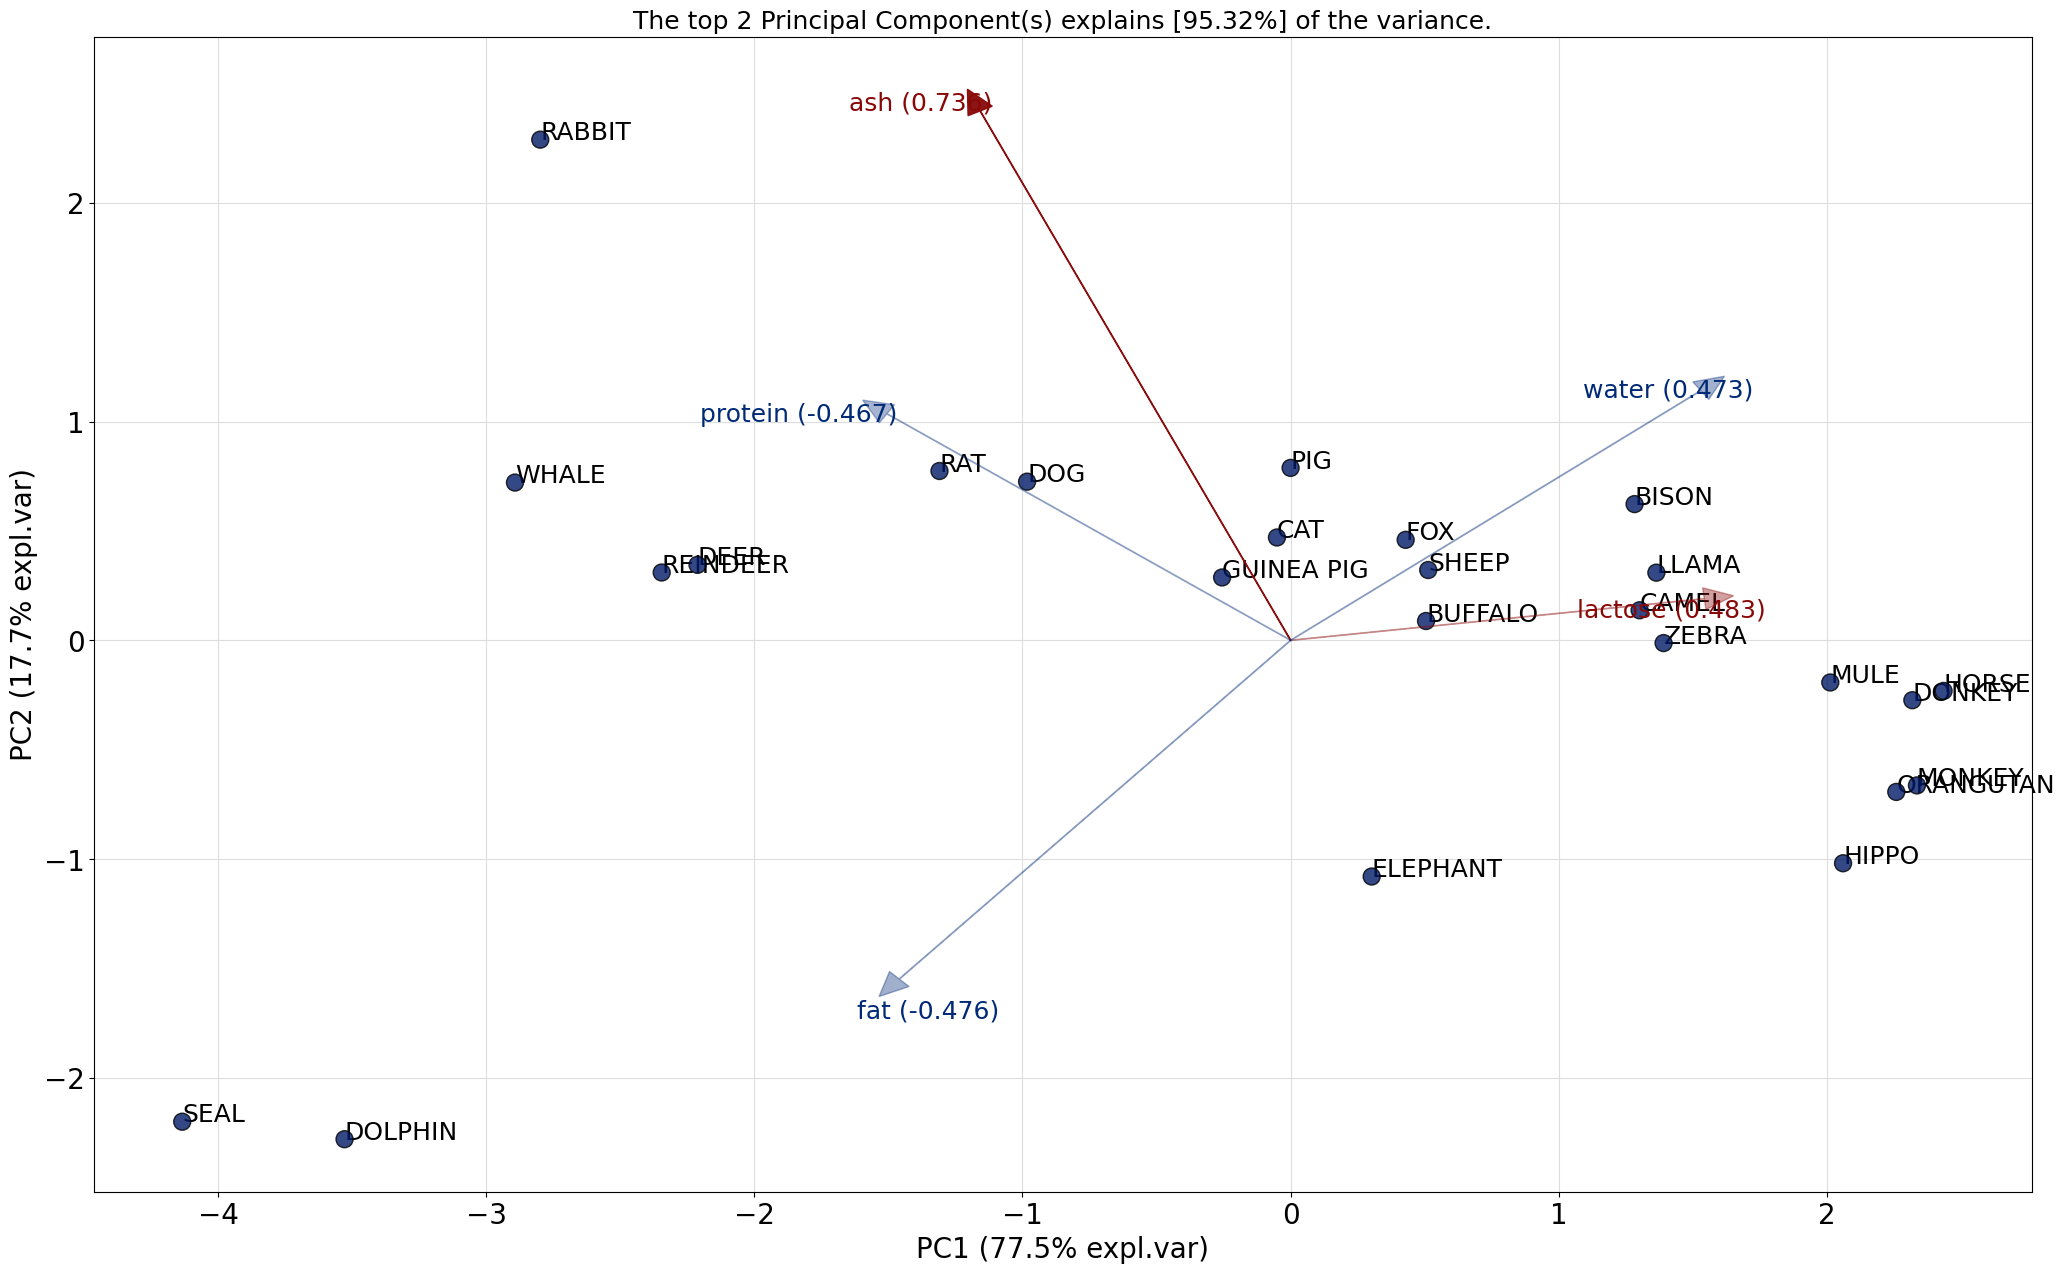

In [14]:
model=pca()
results=model.fit_transform(milk_scaled,
                           col_labels=milk.columns,
                           row_labels=list(milk.index))
model.biplot(label=True,legend=True)
for i in np.arange(0,milk.shape[0]):
    plt.text(pc_data.values[i,0],
            pc_data.values[i,1],
            list(milk.index)[i])
plt.show()

## nutrient 

In [15]:
ntr=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\nutrient.csv",index_col=0)
ntr

,energy,protein,fat,calcium,iron
Food_Item,,,,,
BEEF BRAISED,340,20,28,9,2.6
HAMBURGER,245,21,17,9,2.7
BEEF ROAST,420,15,39,7,2.0
BEEF STEAK,375,19,32,9,2.6
BEEF CANNED,180,22,10,17,3.7
CHICKEN BROILED,115,20,3,8,1.4
CHICKEN CANNED,170,25,7,12,1.5
BEEF HEART,160,26,5,14,5.9
LAMB LEG ROAST,265,20,20,9,2.6


In [16]:
ntr.shape

(27, 5)

In [17]:
scaler=StandardScaler().set_output(transform="pandas")
ntr_scaled=scaler.fit_transform(ntr)

In [18]:
prcomp=PCA().set_output(transform="pandas")
pc_data=prcomp.fit_transform(ntr_scaled)
pc_data.var()

pca0    2.280797
pca1    1.189962
pca2    0.880318
pca3    0.839567
pca4    0.001663
dtype: float64

In [19]:
pc_data

,pca0,pca1,pca2,pca3,pca4
Food_Item,,,,,
BEEF BRAISED,1.894907,0.318029,-0.003579,0.327156,0.005915
HAMBURGER,0.659812,-0.079563,-0.512841,0.166202,-0.002632
BEEF ROAST,2.936755,1.122724,1.097788,-0.226335,0.003483
BEEF STEAK,2.321069,0.585663,0.239173,0.318095,0.028400
BEEF CANNED,-0.256477,0.054382,-1.168707,0.474857,-0.042641
CHICKEN BROILED,-0.932996,-0.905719,-0.393767,-0.815849,-0.031897
CHICKEN CANNED,-0.185016,-1.564189,-0.789681,0.039419,-0.015362
BEEF HEART,-0.699024,0.346282,-2.595080,1.568667,0.045738
LAMB LEG ROAST,0.937389,0.108904,-0.274877,0.082978,-0.024877


In [20]:
values,vectors=np.linalg.eig(milk_scaled.cov())
print("Eigen Values:",values)

Eigen Values: [4.0404117  0.92437238 0.00656977 0.13429088 0.1026886 ]


In [21]:
vectors

array([[-0.47294379,  0.35285509, -0.70967042,  0.36921298,  0.10893632],
       [ 0.46657047,  0.32094099, -0.1930657 ,  0.15196177, -0.78672876],
       [ 0.44868269, -0.47603724, -0.66831106, -0.30699163,  0.17660367],
       [-0.48289116,  0.05951482, -0.11159049, -0.77642589, -0.38468756],
       [ 0.35232959,  0.73643513,  0.00118661, -0.378825  ,  0.43590982]])

In [22]:
prcomp.components_

array([[ 0.65428251,  0.15073191,  0.63991067, -0.35497845, -0.11704241],
       [ 0.08533006, -0.68933242,  0.19978707, -0.00314436,  0.69109684],
       [ 0.15068976, -0.46268437,  0.21748273,  0.65138247, -0.54001659],
       [ 0.19703438,  0.52649179,  0.13170953,  0.67057536,  0.46579517],
       [ 0.7092977 , -0.10406865, -0.69710352,  0.00316007,  0.01015761]])

[24-04-2026 16:30:59] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 5 columns of the input data.
[24-04-2026 16:30:59] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:30:59] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:30:59] [pca.pca] [INFO] Compute explained variance.
[24-04-2026 16:30:59] [pca.pca] [INFO] The top 4 principal component(s) explains >= 95.00% of the explained variance.
[24-04-2026 16:30:59] [pca.pca] [INFO] The PCA reduction is performed on 5 variables (columns) of the input dataframe.
[24-04-2026 16:30:59] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:30:59] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:30:59] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[4]
[24-04-2026 16:30:59] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[24-04-2026 16:30:59] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[24

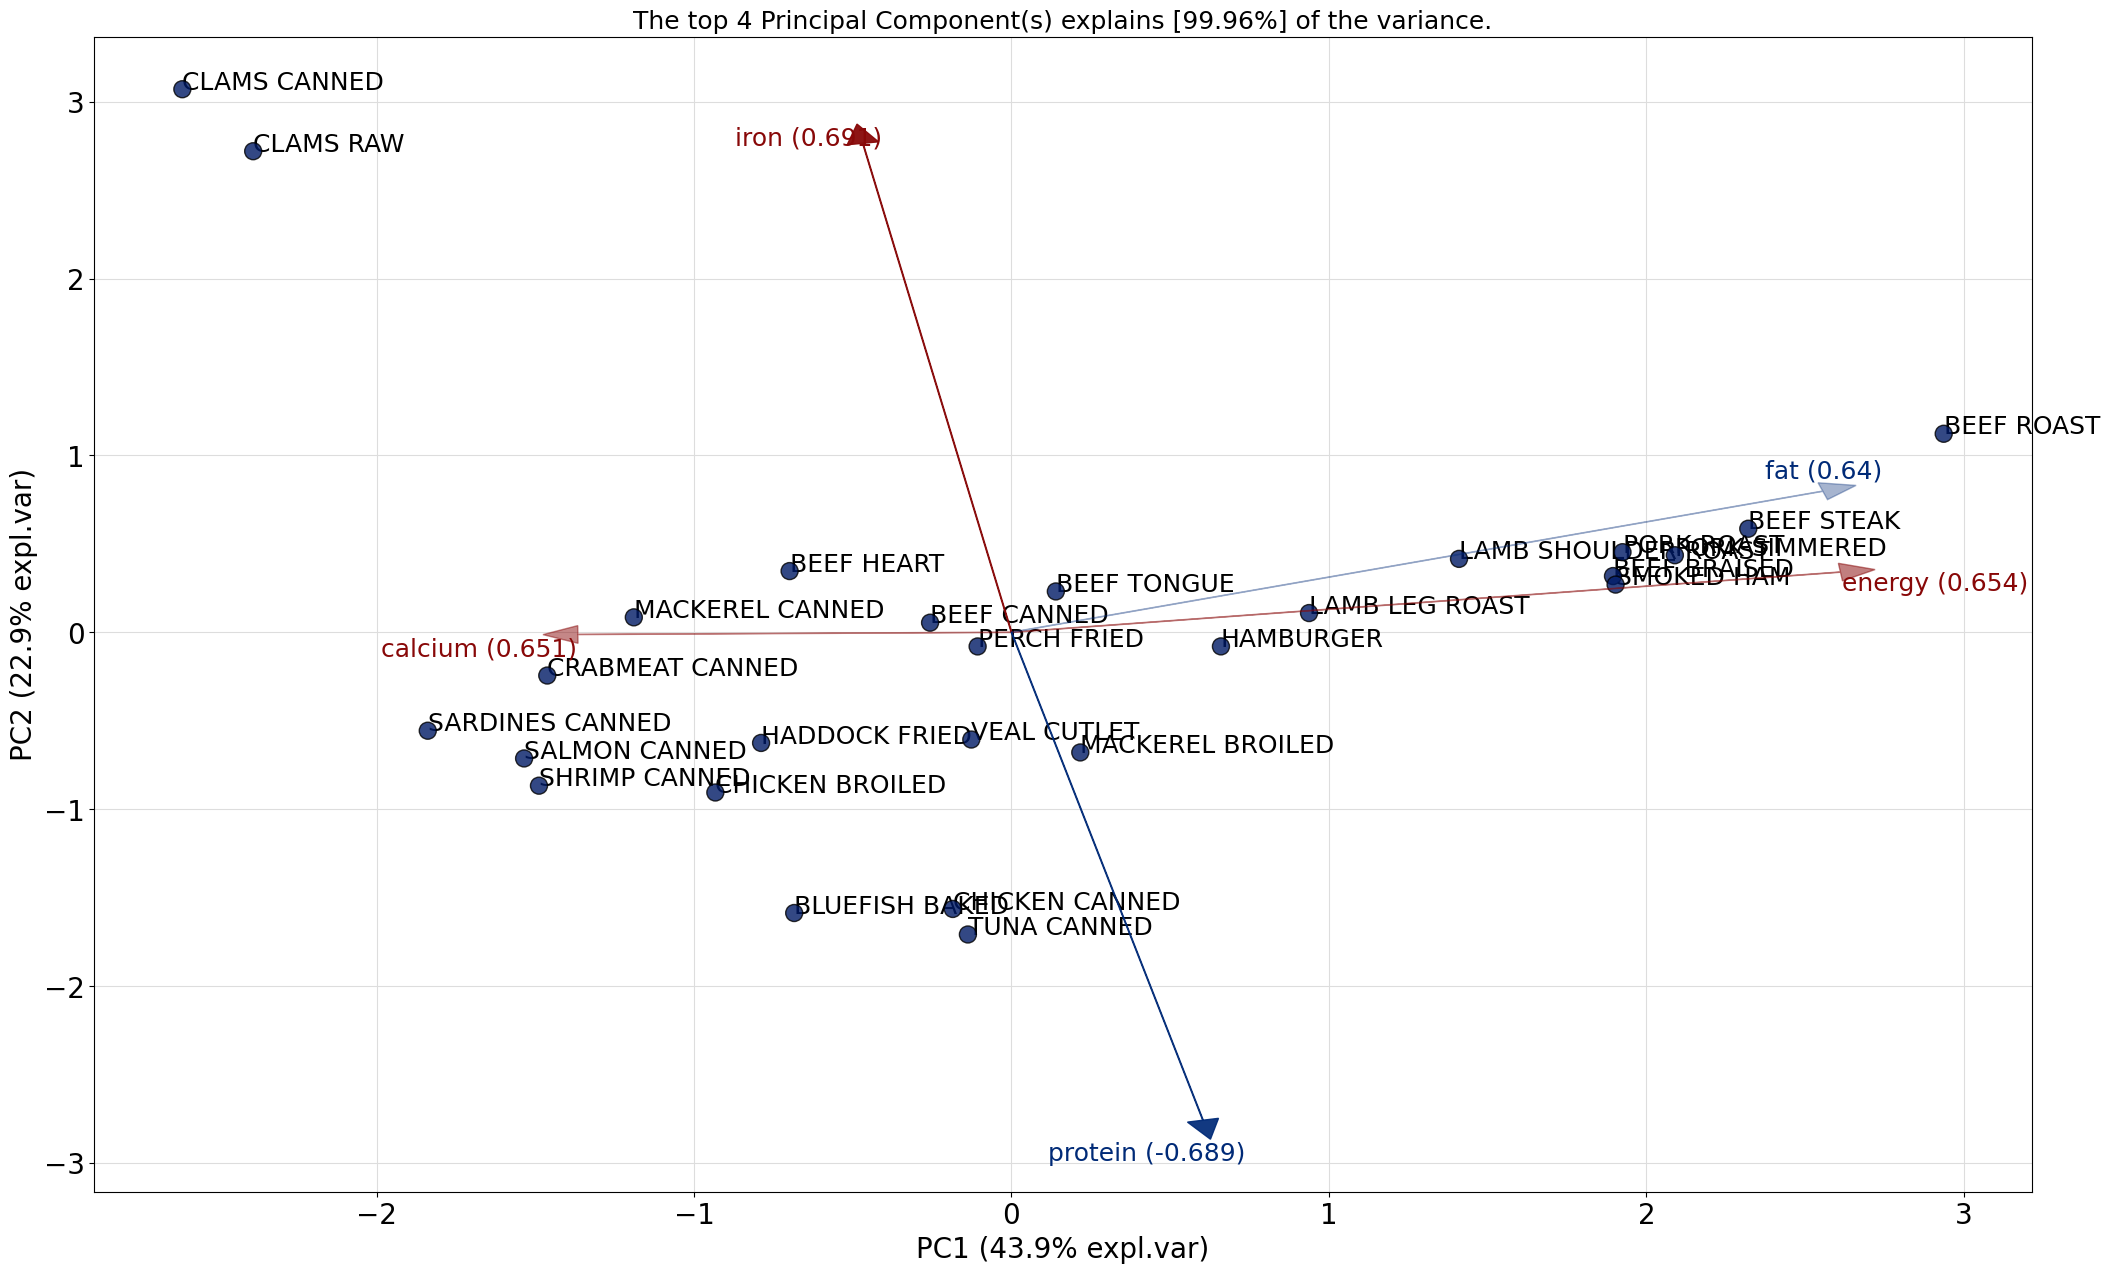

In [23]:
model=pca()
results=model.fit_transform(ntr_scaled,
                           col_labels=ntr.columns,
                           row_labels=list(ntr.index))
model.biplot(label=True,legend=True)
for i in np.arange(0,ntr.shape[0]):
    plt.text(pc_data.values[i,0],
            pc_data.values[i,1],
            list(ntr.index)[i])
plt.show()

## USArrests

In [24]:
arres=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\USArrests.csv",index_col=0)
arres

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9
Georgia,17.4,211,60,25.8


In [25]:
ntr.shape

(27, 5)

In [26]:
scaler=StandardScaler().set_output(transform="pandas")
arres_scaled=scaler.fit_transform(arres)

In [27]:
prcomp=PCA().set_output(transform="pandas")
pc_data=prcomp.fit_transform(arres_scaled)
pc_data.var()

pca0    2.530859
pca1    1.009964
pca2    0.363840
pca3    0.176969
dtype: float64

In [28]:
pc_data

,pca0,pca1,pca2,pca3
Alabama,0.985566,-1.133392,-0.444269,-0.156267
Alaska,1.950138,-1.073213,2.040003,0.438583
Arizona,1.763164,0.745957,0.054781,0.834653
Arkansas,-0.141420,-1.119797,0.114574,0.182811
California,2.523980,1.542934,0.598557,0.341996
Colorado,1.514563,0.987555,1.095007,-0.001465
Connecticut,-1.358647,1.088928,-0.643258,0.118469
Delaware,0.047709,0.325359,-0.718633,0.881978
Florida,3.013042,-0.039229,-0.576829,0.096285
Georgia,1.639283,-1.278942,-0.342460,-1.076797


In [29]:
values,vectors=np.linalg.eig(arres_scaled.cov())
print("Eigen Values:",values)

Eigen Values: [2.53085875 1.00996444 0.17696948 0.36383998]


In [30]:
vectors

array([[ 0.53589947,  0.41818087,  0.6492278 , -0.34123273],
       [ 0.58318363,  0.1879856 , -0.74340748, -0.26814843],
       [ 0.27819087, -0.87280619,  0.13387773, -0.37801579],
       [ 0.54343209, -0.16731864,  0.08902432,  0.81777791]])

[24-04-2026 16:31:00] [pca.pca] [INFO] Column labels are auto-completed.
[24-04-2026 16:31:00] [pca.pca] [INFO] Row labels are auto-completed.
[24-04-2026 16:31:00] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 4 columns of the input data.
[24-04-2026 16:31:00] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:31:00] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:31:00] [pca.pca] [INFO] Compute explained variance.
[24-04-2026 16:31:00] [pca.pca] [INFO] The top 3 principal component(s) explains >= 95.00% of the explained variance.
[24-04-2026 16:31:00] [pca.pca] [INFO] The PCA reduction is performed on 4 variables (columns) of the input dataframe.
[24-04-2026 16:31:00] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:31:00] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:31:00] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[3]
[24-04-2026 16:31:00] [pca.pca] [INFO] Multiple test

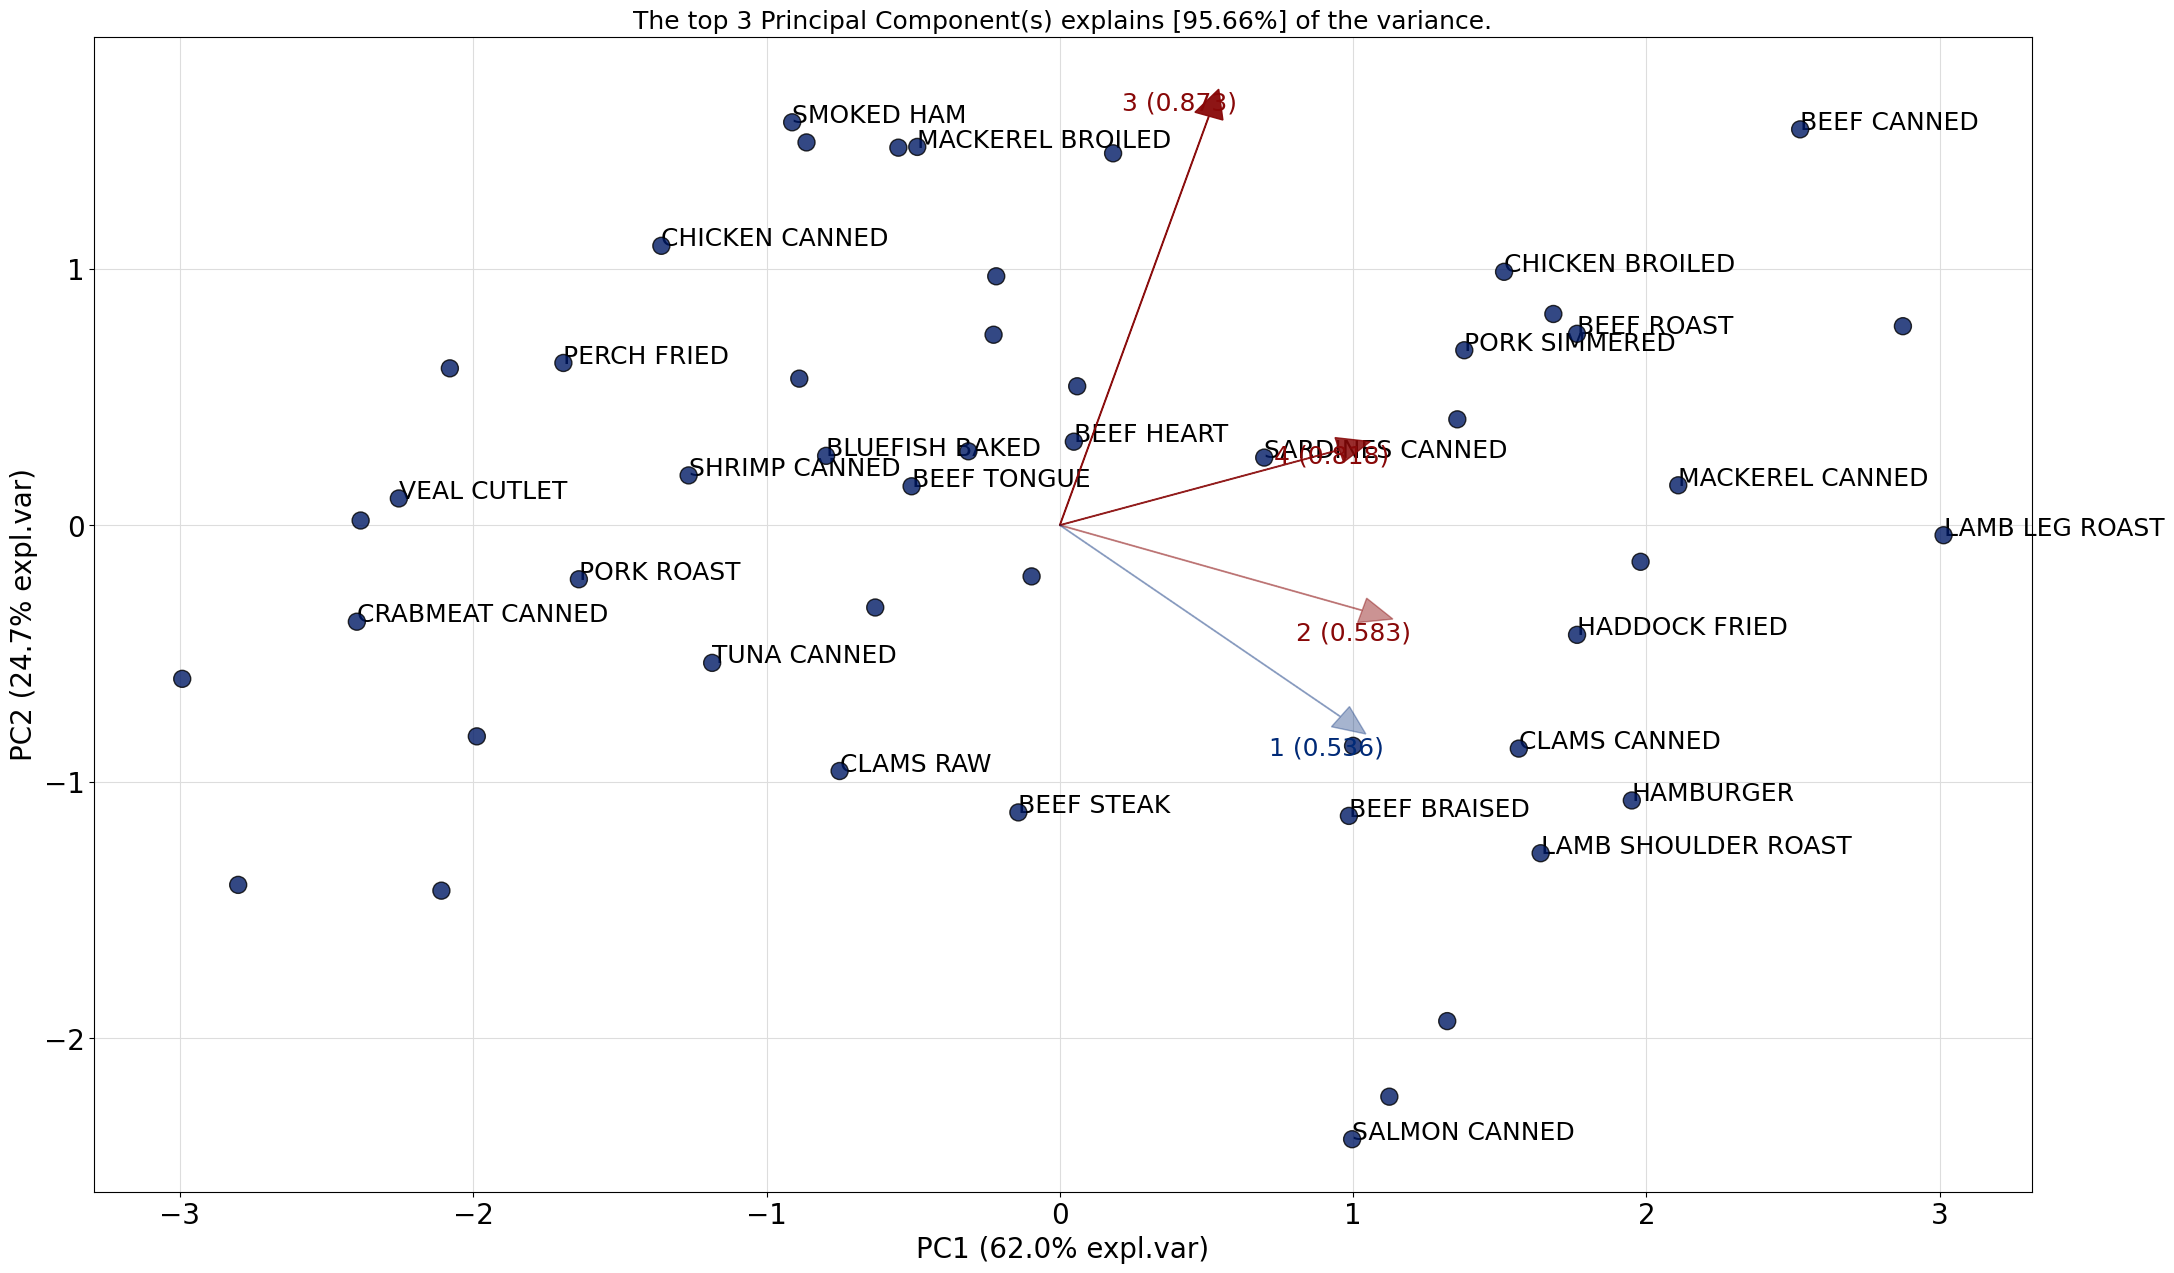

In [31]:
model=pca()
results=model.fit_transform(arres_scaled,
                           col_labels=ntr.columns,
                           row_labels=list(ntr.index))
model.biplot(label=True,legend=True)
for i in np.arange(0,ntr.shape[0]):
    plt.text(pc_data.values[i,0],
            pc_data.values[i,1],
            list(ntr.index)[i])
plt.show()